## `CHM856-810` and `CHM553-909` Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set the default font family
plt.rcParams['font.family'] = 'Arial'

# --- 1. DATA LOADING & PRE-CLEANING ---
########################################################################################
# Load the csv file and Basic cleaning: drop completely empty rows and columns
df_initial = (
    pd.read_csv('Data.csv', sep=',', encoding='utf8', low_memory=False)
    .replace(r'^\s*$', pd.NA, regex=True)
    .loc[:, lambda d: d.notna().any()]
)

# Drop row directly from the original DataFrame
df_initial.drop(0, inplace=True)
df_initial.reset_index(drop=True, inplace=True)

# Dropping those Rows in DataFrame which are completely empty i.e. NaN
df_initial.dropna(how = 'all', inplace=True)

# Getting 'Parameters' and 'Values' from the DataFrame
df_Parameters =  df_initial.loc[:, 'Set':'Parameter_10']
df_Values = df_initial.loc[:, 'Mval_01.1':'Remarks']

# Dropping the last Column ('Remarks') from df_Values
df_Values = df_Values.drop(columns=['Remarks'])

################################################
# Convert whole dataframe to string in Pandas
df_Parameters = df_Parameters.astype(str)
################################################

# Convert non-numeric/string values to NaN
df_Values = df_Values.apply(pd.to_numeric, errors='coerce')

# Merging 2 DataFrames
df_merged = pd.concat([df_Parameters, df_Values], axis=1)

print(df_merged.shape)

(16889, 28)


In [2]:
# Filter Parameter_1 using 'query' Function 
df_merged = df_merged.query("Parameter_1 == 'Sub-I' |  Parameter_1 == 'Sub-II' ")
print(df_merged['Parameter_1'].unique())

['Sub-II' 'Sub-I']


### Filtering 'CHM856-810' and 'CHM553-909' from 'Chem1' and 'Chem6' Columns

In [3]:
# Search strings
search_string1 = '856'
search_string2 = '810'
search_string3 = '553'
search_string4 = '909'

df_ROP = df_merged[((df_merged['Chem1'].str.contains(search_string1, 
                                                        case=False, regex=True)) &
        (df_merged['Chem6'].astype(str).str.contains(search_string2, 
                                                              case=False, regex=True))) |
        ((df_merged['Chem1'].str.contains(search_string3, case=False, regex=True)) &
        (df_merged['Chem6'].astype(str).str.contains(search_string4, 
                                                              case=False, regex=True)))]

print(df_ROP.shape)
df_ROP[['Chem1', 'Chem6']].drop_duplicates();

(4205, 28)


In [4]:
df_ROP[['Chem4', 'Parameter_2', 'Parameter_3', 'Parameter_4',
        'Parameter_5', 'Parameter_6']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4205 entries, 158 to 17673
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Chem4        4205 non-null   object
 1   Parameter_2  4205 non-null   object
 2   Parameter_3  4205 non-null   object
 3   Parameter_4  4205 non-null   object
 4   Parameter_5  4205 non-null   object
 5   Parameter_6  4205 non-null   object
dtypes: object(6)
memory usage: 230.0+ KB


### More Filtering: 'Chem4', 'Parameter_2', 'Parameter_3' and 'Parameter_4'

In [5]:
df_ROP = df_ROP[(df_ROP['Chem4']=='15') & (df_ROP['Parameter_2']=='100') & 
                (df_ROP['Parameter_3']=='90') & (df_ROP['Parameter_4']=='80') & 
                (df_ROP['Parameter_5']=='40') & (df_ROP['Parameter_6']=='200')]

print(df_ROP.shape)
df_ROP[['Chem1']].drop_duplicates();

(3081, 28)


### Replace '856' with 'CHM856-810' and '553' with 'CHM553-909'

In [6]:
# Replace any variation of '856' with 'CHM856-810' and any variation of '553' with 'CHM553-909'
df_ROP.loc[:, 'Chem1'] = df_ROP['Chem1'].replace({
    r'.*856[\W_]?.*': 'CHM856-810',
    r'.*553[\W_]?.*': 'CHM553-909' 
}, regex=True)

print(df_ROP.shape)
df_ROP[['Chem1']].drop_duplicates()

(3081, 28)


,Chem1
158,CHM856-810
12221,CHM553-909


In [7]:
# Create 2 different dataframes using a filter function (query)
df_CHM856 = df_ROP.query("Chem1 == 'CHM856-810'")
df_CHM553 = df_ROP.query("Chem1 == 'CHM553-909'")

### Formulation-1: 6σ Calculation

In [8]:
# Filter Mval_02 Values using 'query' Function 
df_CHM856 = df_CHM856.query('Mval_02 < 89 and Mval_02 > 87')

# Select columns starting with 'Mval_02'
angle_cols = df_CHM856.loc[:, df_CHM856.columns.str.startswith("Mval_02")]

# Assuming a single Angle column, flatten values and drop NaNs
values = angle_cols.values.flatten()
values = values[~np.isnan(values)]

# Calculate statistics
mean_val = np.mean(values)
std_val = np.std(values)          # population std (use ddof=1 for sample std)
six_sigma = 6 * std_val

lower_limit = mean_val - six_sigma
upper_limit = mean_val + six_sigma

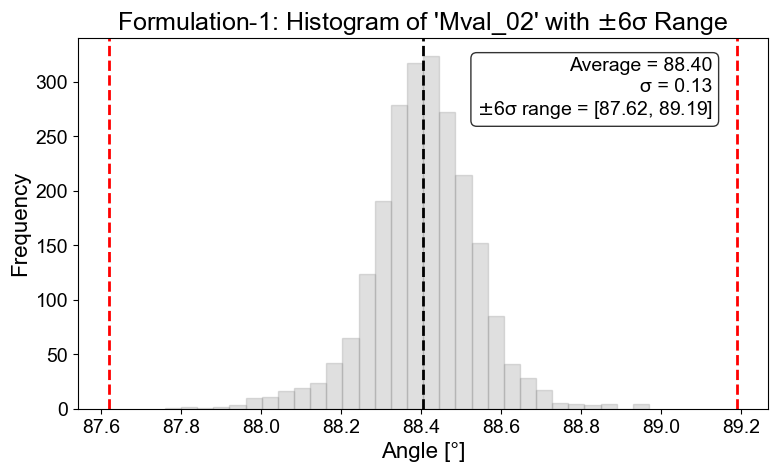

In [9]:
# Plot histogram
plt.rcParams.update({'font.size': 14})
#plt.figure(figsize=(10, 6.18))
plt.figure(figsize=(8, 4.944))

plt.hist(values, bins=30, color='gray', alpha=.25, edgecolor='gray')

# Mean line
plt.axvline(mean_val, color='black', linestyle='dashed', linewidth=2, 
            label=f'Mean = {mean_val:.2f}')

# ±6 sigma lines (12 sigma apart)
plt.axvline(lower_limit, color='red', linestyle='dashed', linewidth=2, 
            label=f'-6σ = {lower_limit:.2f}')
plt.axvline(upper_limit, color='red', linestyle='dashed', linewidth=2, 
            label=f'+6σ = {upper_limit:.2f}')

# Text box with statistics
textstr = (f'Average = {mean_val:.2f}\n'
           #f'StdDev = {std_val:.2f}\n'
           f'σ = {std_val:.2f}\n'
           #f'6σ = {six_sigma:.2f}\n'
           f'$\pm$6σ range = [{lower_limit:.2f}, {upper_limit:.2f}]')
plt.gca().text(0.92, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=14, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Angle [°]', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title("Formulation-1: Histogram of 'Mval_02' with $\pm$6σ Range", fontsize=18)
#plt.legend()
plt.tight_layout()

# File saving
#plt.savefig('Formulation-1.png', bbox_inches="tight", transparent=False, dpi=300)
#plt.savefig('StatisticalPlot_1.png', bbox_inches="tight", transparent=False, dpi=300)
plt.show()

### Formulation-2: 6σ Calculation

In [10]:
# Filter Mval_02 Values using 'query' Function 
df_CHM553 = df_CHM553.query('Mval_02 < 87.5 and Mval_02 > 86')

# Select columns starting with 'Mval_02'
angle_cols = df_CHM553.loc[:, df_CHM553.columns.str.startswith("Mval_02")]

# Assuming a single angle column, flatten values and drop NaNs
values = angle_cols.values.flatten()
values = values[~np.isnan(values)]

# Calculate statistics
mean_val = np.mean(values)
std_val = np.std(values)          # population std (use ddof=1 for sample std)
six_sigma = 6 * std_val

lower_limit = mean_val - six_sigma
upper_limit = mean_val + six_sigma

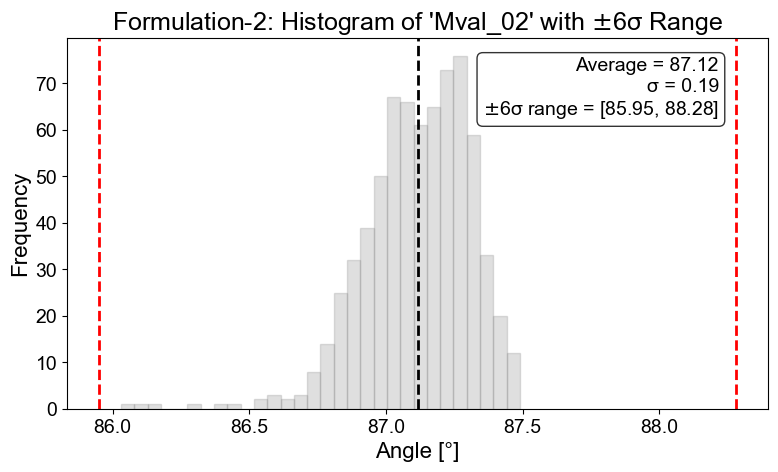

In [11]:
# Plot histogram
plt.rcParams.update({'font.size': 14})
#plt.figure(figsize=(10, 6.18))
plt.figure(figsize=(8, 4.944))
plt.hist(values, bins=30, color='gray', alpha=.25, edgecolor='gray')

# Mean line
plt.axvline(mean_val, color='black', linestyle='dashed', linewidth=2, 
            label=f'Mean = {mean_val:.2f}')

# ±6 sigma lines (12 sigma apart)
plt.axvline(lower_limit, color='red', linestyle='dashed', linewidth=2, 
            label=f'-6σ = {lower_limit:.2f}')
plt.axvline(upper_limit, color='red', linestyle='dashed', linewidth=2, 
            label=f'+6σ = {upper_limit:.2f}')

# Text box with statistics
textstr = (f'Average = {mean_val:.2f}\n'
           #f'StdDev = {std_val:.2f}\n'
           f'σ = {std_val:.2f}\n'
           #f'6σ = {six_sigma:.2f}\n'
           f'$\pm$6σ range = [{lower_limit:.2f}, {upper_limit:.2f}]')
plt.gca().text(0.93, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=14, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Angle [°]', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title("Formulation-2: Histogram of 'Mval_02' with $\pm$6σ Range", fontsize=18)
#plt.legend()
plt.tight_layout()

# File saving
#plt.savefig('Formulation-2.png', bbox_inches="tight", transparent=False, dpi=300)
plt.savefig('StatisticalPlot_2.png', bbox_inches="tight", transparent=False, dpi=300)
plt.show()